# Synthetic data generation for BCMLS2 workshop

A <-> B

* Known initial conditions: A0 = 1, B0 = 0
* Observable: obs_B := B
* Unknown parameters: k_ab, k_ba

In [1]:
import amici
from amici.importers.antimony import antimony2amici
import numpy as np
from scipy.stats import norm
import pandas as pd

np.random.seed(0)

In [2]:
antimony_model = """
model conversion_example
    A0 = 1
    B0 = 0
    species A = A0, B = B0
    R_ab: A -> B; k_ab * A
    R_ba: B -> A; k_ba * B
    k_ab = 0.5
    k_ba = 0.5
end
"""
amici_model: amici.sim.sundials.Model = antimony2amici(antimony_model, model_name="conversion_example")

In [3]:
# ground truth
k_ab = 0.28
k_ba = 0.14
sd = 0.05
KD = k_ba / k_ab
print(f"KD = {KD:.2f}")

KD = 0.50


## Dataset 1 -- late time points

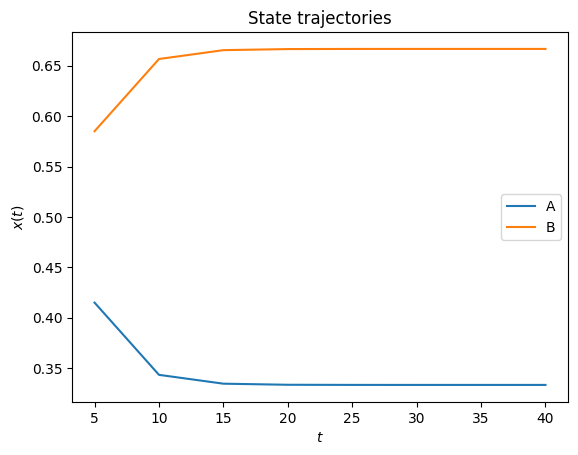

In [4]:
amici_model.set_timepoints(np.linspace(1, 8, 8) * 5)
amici_model.set_free_parameter_by_id("k_ab", k_ab)
amici_model.set_free_parameter_by_id("k_ba", k_ba)
rdata = amici_model.simulate()

from amici.sim.sundials.plotting import plot_state_trajectories, \
    plot_observable_trajectories

plot_state_trajectories(rdata)

In [5]:
df_mes = pd.DataFrame(rdata.xr.x.loc[:, "B"].to_pandas().rename("B"))
df_mes.B = df_mes.B + norm.rvs(scale=sd, size=df_mes.shape[0])
df_mes.to_csv("measurement_for_petabgui.csv")

In [6]:
# create petab problem
import petab.v1 as petab1
from pathlib import Path
from petab.v1.models.sbml_model import SbmlModel

petab_dir = Path("petab_problem")
petab_dir.mkdir(parents=True, exist_ok=True)

SbmlModel.from_antimony(antimony_model).to_file(petab_dir / "model.xml")

config = {
    petab1.FORMAT_VERSION: 1,
    petab1.PARAMETER_FILE: "parameters.tsv",
    petab1.PROBLEMS: [
        {
            petab1.SBML_FILES: ["model.xml"],
            petab1.OBSERVABLE_FILES: ["observables.tsv"],
            petab1.MEASUREMENT_FILES: ["measurements.tsv"],
            petab1.CONDITION_FILES: ["conditions.tsv"],
        }
    ]
}
petab1.write_yaml(config, petab_dir / "problem.yaml")

obs_df = pd.DataFrame({
    "observableId": ["obs_B"],
    "observableFormula": ["B"],
    "noiseDistribution": ["normal"],
    "noiseFormula": [sd]
})
petab1.write_observable_df(obs_df, petab_dir / "observables.tsv")

mes_df = pd.DataFrame({
    "observableId": ["obs_B"] * len(df_mes),
    "time": df_mes.index,
    "measurement": df_mes.B,
})
mes_df[petab1.SIMULATION_CONDITION_ID] = "experiment1"
petab1.write_measurement_df(mes_df, petab_dir / "measurements.tsv")

cond_df = pd.DataFrame({
    "conditionId": ["experiment1"],
})
petab1.write_condition_df(cond_df, petab_dir / "conditions.tsv")

par_df = pd.DataFrame({
    "parameterId": ["k_ab", "k_ba"],
    "estimate": [1, 1],
    "parameterScale": ["lin", "lin"],
    "lowerBound": [0, 0],
    "upperBound": [10, 10],
    #"nominalValue": [0.8, 0.2],
})
petab1.write_parameter_df(par_df, petab_dir / "parameters.tsv")

problem = petab1.Problem.from_yaml(petab_dir / "problem.yaml")
assert petab1.lint_problem(problem) is False

Visualization table not available. Skipping.


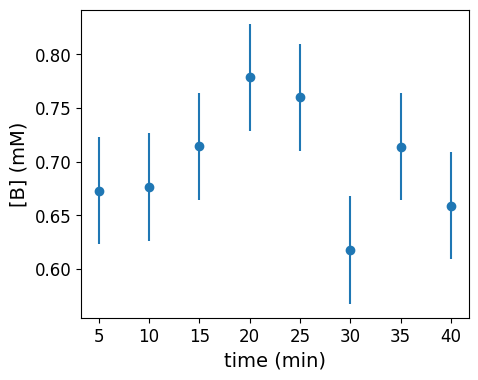

In [7]:
import matplotlib.pyplot as plt
x, y = df_mes.index, df_mes.B

with plt.rc_context({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
}):
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.errorbar(x, y, yerr=sd, fmt="o", label="data")
    ax.set_xlabel("time (min)")
    ax.set_ylabel("[B] (mM)")


## Dataset 2 -- early time points

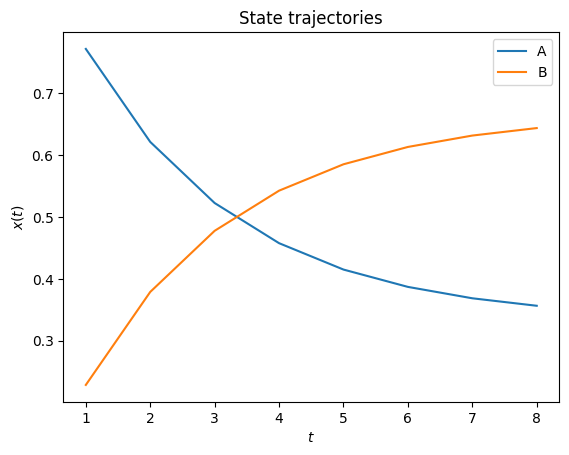

In [8]:
amici_model.set_timepoints(np.arange(1.0, 9.0))
rdata = amici_model.simulate()

from amici.sim.sundials.plotting import plot_state_trajectories, \
    plot_observable_trajectories

plot_state_trajectories(rdata)

In [9]:
df_mes = pd.DataFrame(rdata.xr.x.loc[:, "B"].to_pandas().rename("B"))
df_mes.B = df_mes.B + norm.rvs(scale=sd, size=df_mes.shape[0])
df_mes.to_csv("measurement2_for_petabgui.csv")

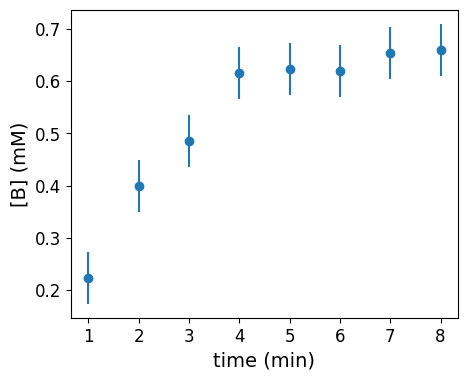

In [10]:
x, y = df_mes.index, df_mes.B

with plt.rc_context({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
}):
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.errorbar(x, y, yerr=sd, fmt="o", label="data")
    ax.set_xlabel("time (min)")
    ax.set_ylabel("[B] (mM)")

In [11]:
mes_df = pd.DataFrame({
    "observableId": ["obs_B"] * len(df_mes),
    "time": df_mes.index,
    "measurement": df_mes.B,
})
mes_df[petab1.SIMULATION_CONDITION_ID] = "experiment1"
petab1.write_measurement_df(mes_df, petab_dir / "measurements2.tsv")


In [12]:
config = {
    petab1.FORMAT_VERSION: 1,
    petab1.PARAMETER_FILE: "parameters.tsv",
    petab1.PROBLEMS: [
        {
            petab1.SBML_FILES: ["model.xml"],
            petab1.OBSERVABLE_FILES: ["observables.tsv"],
            petab1.MEASUREMENT_FILES: ["measurements.tsv", "measurements2.tsv"],
            petab1.CONDITION_FILES: ["conditions.tsv"],
        }
    ]
}
petab1.write_yaml(config, petab_dir / "problem2.yaml")

problem = petab1.Problem.from_yaml(petab_dir / "problem2.yaml")
assert petab1.lint_problem(problem) is False

Visualization table not available. Skipping.
